In [139]:
import pandas as pd
from dotenv import load_dotenv
import psycopg2
import os
import numpy as np

In [119]:
load_dotenv()
url = os.getenv("DATABASE_URL")

In [144]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

query = """
SELECT timestamp, ticker, side, volume, price FROM orders
ORDER BY volume DESC
"""
cur.execute(query)
rows = cur.fetchall()

In [145]:
df = pd.DataFrame(rows, columns=['timestamp', 'ticker', 'side', 'volume', 'price'])
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.head()

,ticker,side,volume,price
timestamp,,,,
2026-04-29 16:47:14+00:00,SR320CF6,SELL,270000,12
2026-04-01 10:56:46+00:00,SR310CD6B,BUY,153143,8
2026-03-26 15:18:50+00:00,SR320CP6A,SELL,74862,4
2026-03-25 11:46:13+00:00,SR310CD6,BUY,63350,12
2026-03-25 06:19:33+00:00,SR310CC6D,BUY,51150,9


In [146]:
df.describe()

,volume,price
count,9912.000000,9912.000000
mean,1582.101493,5.803370
std,5143.079989,7.397118
min,0.000000,0.000000
25%,22.000000,0.000000
50%,116.000000,3.000000
75%,816.000000,9.000000
max,270000.000000,55.000000


In [147]:
buy_df = df[df['side'] == "BUY"]
buy_df.head()

,ticker,side,volume,price
timestamp,,,,
2026-04-01 10:56:46+00:00,SR310CD6B,BUY,153143,8
2026-03-25 11:46:13+00:00,SR310CD6,BUY,63350,12
2026-03-25 06:19:33+00:00,SR310CC6D,BUY,51150,9
2026-04-24 19:06:47+00:00,SR320CE6A,BUY,48182,8
2026-04-17 13:44:19+00:00,SR310CF6,BUY,47000,23


In [148]:
top_10_buy_df = buy_df.head(100)
top_10_buy_df

,ticker,side,volume,price
timestamp,,,,
2026-04-01 10:56:46+00:00,SR310CD6B,BUY,153143,8
2026-03-25 11:46:13+00:00,SR310CD6,BUY,63350,12
2026-03-25 06:19:33+00:00,SR310CC6D,BUY,51150,9
2026-04-24 19:06:47+00:00,SR320CE6A,BUY,48182,8
2026-04-17 13:44:19+00:00,SR310CF6,BUY,47000,23
...,...,...,...,...
2026-04-30 10:24:19+00:00,SR300CE6,BUY,18344,22
2026-03-31 06:57:45+00:00,SR280CD6,BUY,18300,36
2026-04-03 17:58:51+00:00,SR330CP6B,BUY,18287,14


In [149]:
query = """
SELECT timestamp, ticker, bids, asks FROM orderbooks
WHERE ticker = ANY(%s)
"""
tickers = top_10_buy_df['ticker'].unique().tolist()
cur.execute(query, (tickers,))
rows = cur.fetchall()

In [150]:
orderbooks_df = pd.DataFrame(rows, columns=['timestamp', 'ticker', 'bids', 'asks'])
orderbooks_df['timestamp'] = pd.to_datetime(orderbooks_df['timestamp'])
orderbooks_df.set_index('timestamp', inplace=True)
orderbooks_df.head()

,ticker,bids,asks
timestamp,,,
2026-04-20 11:35:35+00:00,SR320CQ6,"[{'price': 2.78, 'quantity': 3600}, {'price': ...","[{'price': 3.21, 'quantity': 2000}, {'price': ..."
2026-04-20 11:35:36+00:00,SR320CQ6,"[{'price': 2.78, 'quantity': 3600}, {'price': ...","[{'price': 3.21, 'quantity': 2000}, {'price': ..."
2026-04-20 11:35:38+00:00,SR300CE6,"[{'price': 27.45, 'quantity': 800}, {'price': ...","[{'price': 28.56, 'quantity': 200}, {'price': ..."
2026-04-20 11:35:39+00:00,SR320CE6,"[{'price': 10.8, 'quantity': 800}, {'price': 1...","[{'price': 11.65, 'quantity': 5500}, {'price':..."
2026-04-20 11:35:39+00:00,SR320CQ6,"[{'price': 2.78, 'quantity': 3600}, {'price': ...","[{'price': 3.21, 'quantity': 2000}, {'price': ..."


In [151]:
orderbooks_df['best_bid'] = orderbooks_df['bids'].apply(lambda bids: bids[0]['price'] if bids else None)
orderbooks_df['best_ask'] = orderbooks_df['asks'].apply(lambda asks: asks[0]['price'] if asks else None)
orderbooks_df['mid_price'] = orderbooks_df['best_bid'] + (orderbooks_df['best_ask'] - orderbooks_df['best_bid'])/2
prices_df = orderbooks_df[['ticker', 'mid_price']]
prices_df.head()

,ticker,mid_price
timestamp,,
2026-04-20 11:35:35+00:00,SR320CQ6,2.995
2026-04-20 11:35:36+00:00,SR320CQ6,2.995
2026-04-20 11:35:38+00:00,SR300CE6,28.005
2026-04-20 11:35:39+00:00,SR320CE6,11.225
2026-04-20 11:35:39+00:00,SR320CQ6,2.995


In [152]:
top_10_buy_df = top_10_buy_df.sort_index()
prices_df = prices_df.sort_values(['ticker', 'timestamp'])

In [153]:
base = pd.merge_asof(
    top_10_buy_df.sort_index(),
    prices_df.sort_values('timestamp'),
    left_on='timestamp',
    right_on='timestamp',
    by='ticker',
    direction='backward'
).rename(columns={'mid_price': 'mid_0'})

In [154]:
horizons = ['5min', '15min', '45min','1h', '4h', '8h', '12h', '1D', '3D', '7D']

base = base.reset_index(drop=True)

prices_sorted = prices_df.sort_values('timestamp')

for h in horizons:
    tmp = base.copy()

    tmp['target_time'] = tmp['timestamp'] + pd.Timedelta(h)

    tmp = tmp.sort_values('target_time')

    tmp = pd.merge_asof(
        tmp,
        prices_sorted,
        left_on='target_time',
        right_on='timestamp',
        by='ticker',
        direction='forward'
    )

    base[f'mid_{h}'] = tmp['mid_price'].values

In [156]:
for h in horizons:
    col = f'return_{h}'
    
    base[col] = (base[f'mid_{h}'] - base['price']) / base['price']
    
    base.loc[~np.isfinite(base[col]), col] = np.nan

In [157]:
base[[f'return_{h}' for h in horizons]].describe()

,return_5min,return_15min,return_45min,return_1h,return_4h,return_8h,return_12h,return_1D,return_3D,return_7D
count,97.000000,97.000000,97.000000,96.000000,95.000000,82.000000,73.000000,84.000000,70.000000,60.000000
mean,0.030595,0.027192,0.026870,0.024770,0.020977,0.119382,0.032908,0.030743,0.042436,-0.024568
std,0.039863,0.045456,0.049992,0.054865,0.078215,1.018265,0.122249,0.127877,0.186023,0.281459
min,-0.121000,-0.116000,-0.116000,-0.135000,-0.432500,-0.432500,-0.355500,-0.469000,-0.603000,-0.875833
25%,0.008800,0.003913,0.001957,0.001962,0.001250,-0.012125,-0.021087,-0.030694,0.011991,-0.072759
50%,0.023654,0.024130,0.022414,0.020331,0.021296,0.010615,0.020000,0.031996,0.056509,0.016100
75%,0.044375,0.048148,0.048148,0.048785,0.054969,0.061938,0.075000,0.100788,0.136845,0.155385
max,0.138750,0.155000,0.177273,0.173333,0.254000,9.190862,0.536000,0.403750,0.544000,0.456000


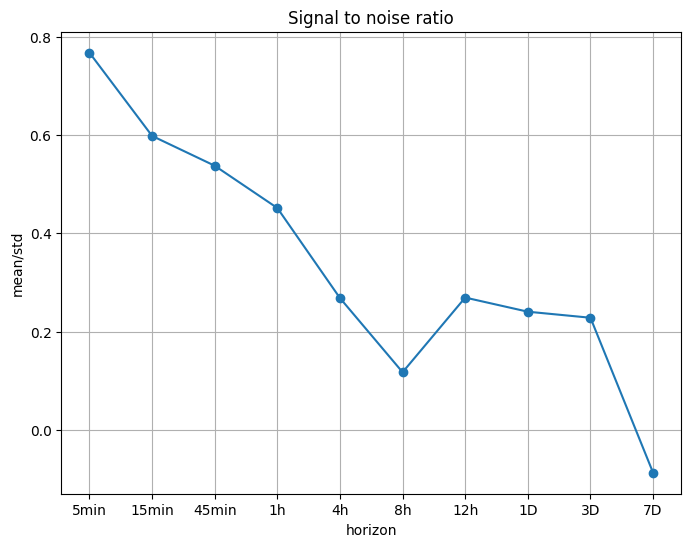

In [158]:
snr = []

for h in horizons:
    col = f'return_{h}'
    s = base[col].dropna()
    snr.append(s.mean() / s.std())

fig = plt.figure(figsize=(8,6))
plt.plot(horizons, snr, marker='o')
plt.title("Signal to noise ratio")
plt.xlabel("horizon")
plt.ylabel("mean/std")
plt.grid()
plt.show()